In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from spinodal_decomp.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




In [3]:
save_fig_dir = "./figures/"

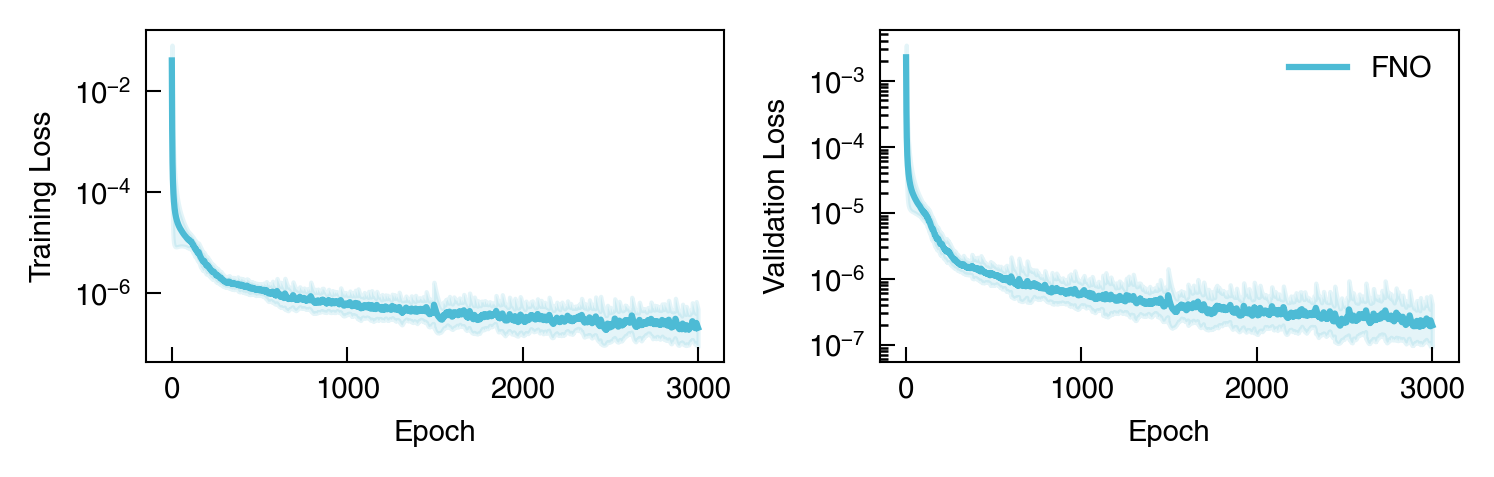

In [4]:
# read csv loss
import pandas as pd
import numpy as np

def moving_average(data, window_size=50, log_scale=False):
    series = pd.Series(data)
    if log_scale:
        series = np.log(series)
        
    # 使用 ewm (指数加权移动平均) 替代 rolling
    # span=window_size，产生的曲线更平滑，阴影边缘也更自然，符合主流论文绘图风格
    mean = series.ewm(span=window_size).mean()
    std = series.ewm(span=window_size).std().fillna(0)
    
    if log_scale:
        avg = np.exp(mean)
        lower = np.exp(mean - std)
        upper = np.exp(mean + std)
    else:
        avg = mean
        lower = mean - std
        upper = mean + std
        
    return avg.values, lower.values, upper.values

save_dir_pino = "/root/autodl-tmp/runs/spinodal_decomp/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/spinodal_decomp/FNO/"
dirs = [
    # (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
]

fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    loss_df = loss_df[loss_df["Epoch"] <= 3000]
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["TrainLoss"].values, log_scale=True,)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name, color="C1")
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.15, color="C1")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    
    avg, lower, upper = moving_average(loss_df["ValidLoss"].values, log_scale=True)
    
    ax.plot(loss_df["Epoch"], avg, label=model_name, color="C1")
    ax.fill_between(loss_df["Epoch"], lower, upper, alpha=0.15, color="C1")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomp_training_validation_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

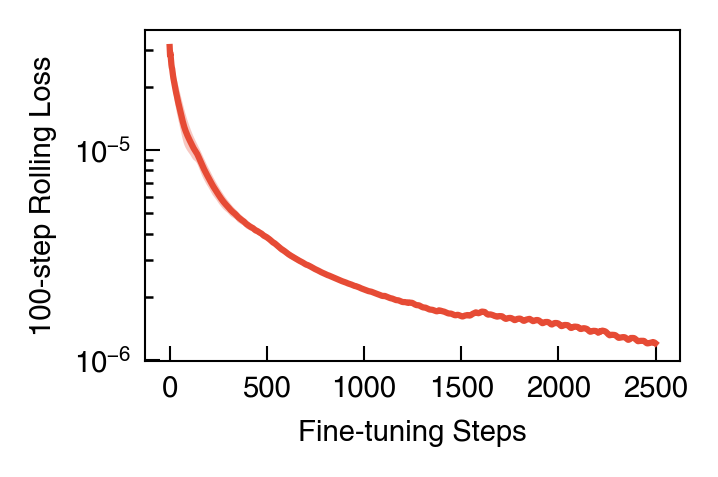

In [5]:
loss = jnp.load("/root/autodl-tmp/runs/spinodal_decomp/FNO/fine_tune_losses.npy")
fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6),)
avg, lower, upper = moving_average(loss, log_scale=True)
ax.plot(np.arange(len(loss)), avg, label="FNO Fine-tune")
ax.fill_between(np.arange(len(loss)), lower, upper, alpha=0.3)
ax.set_yscale("log")
ax.set_ylabel("100-step Rolling Loss")
ax.set_xlabel("Fine-tuning Steps")
fig.tight_layout()
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomp_fine_tune_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

Text(0, 0.5, 'Test MSE Loss (100 steps)')

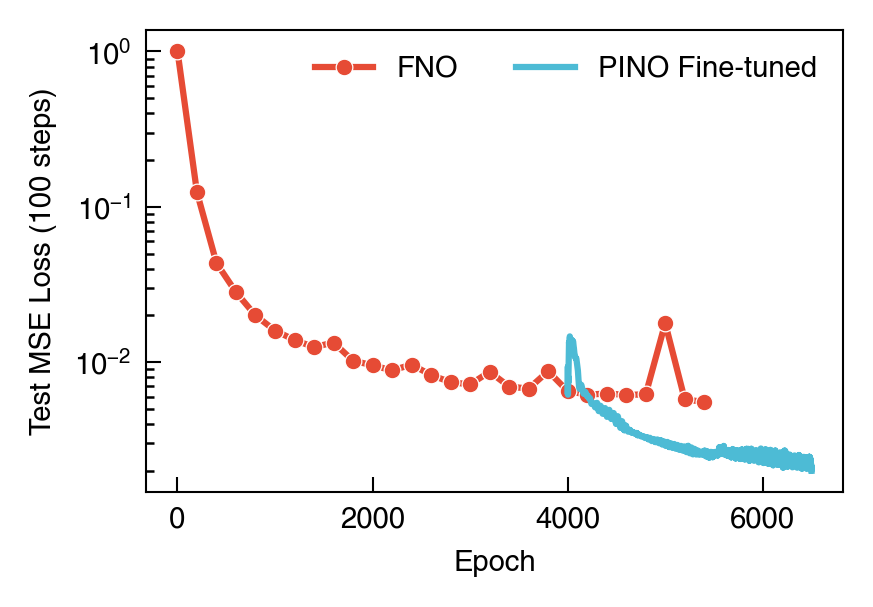

In [6]:

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))


# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
test_df = pd.read_csv("/root/autodl-tmp/runs/spinodal_decomp/FNO/test_logs.csv")
ax.plot(test_df["Epoch"], test_df["TestMSE"], label="FNO", marker='o', 
        markersize=4, markeredgecolor="white", markeredgewidth=0.3)
fine_tuned_error = np.load("/root/autodl-tmp/runs/spinodal_decomp/FNO/fine_tune_mse_errors.npy")
epochs = np.arange(1, fine_tuned_error.shape[0] + 1) + 4000
ax.plot(epochs, fine_tuned_error, label="PINO Fine-tuned", )
    
ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (100 steps)")

## 加载模型并评估

In [7]:
save_fig_dir = "./figures/"

In [8]:
# from model import model1d
from spinodal_decomp.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
weight_fno = os.path.join(save_dir_fno, f"epoch_4000.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

weight_pino = os.path.join(save_dir_fno, f"epoch_finetuned.eqx")
model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)


In [9]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((625, 4, 64, 64), (625, 1, 64, 64))

In [10]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ms = jnp.load(os.path.join(configs.test_data_dir, "M_values.npy"))
start = 0
steps = 100
u0 = test_solutions[:, start, :, :]
y_test = test_solutions[:, start+1:start+1+steps, :, :]

auto_reg_fn_pino = partial(
    model_pino.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds = jax.vmap(auto_reg_fn_pino, in_axes=(0,0))(u0, test_ms)

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds_fno = jax.vmap(auto_reg_fn_fno, in_axes=(0,0))(u0, test_ms)

u_preds.shape, u_preds_fno.shape, y_test.shape

((5, 100, 1, 64, 64), (5, 100, 1, 64, 64), (5, 100, 1, 64, 64))

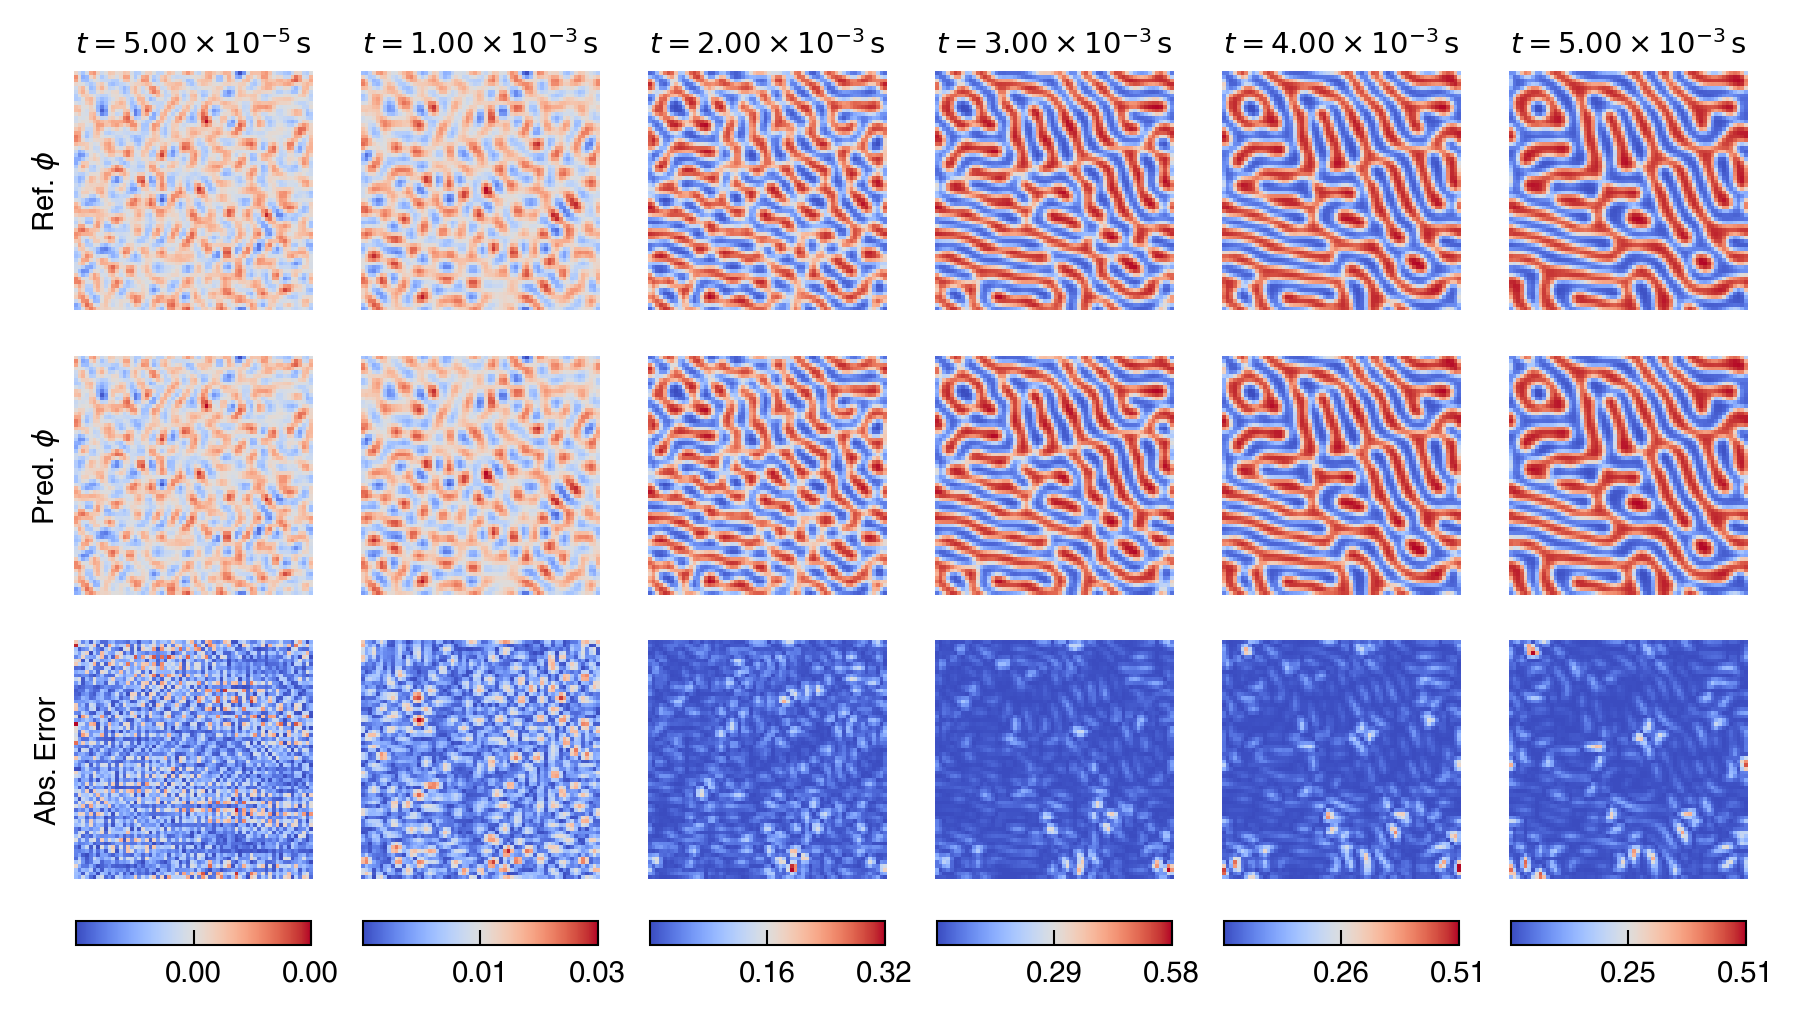

In [11]:
idxs = [0, 19, 39, 59, 79, 99]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0

def num_to_latex(num, precision=2):
    mantissa, exponent = f"{num:.{precision}e}".split("e")
    exponent = int(exponent)
    return f"{mantissa}\\times 10^{{{exponent}}}"


from matplotlib import gridspec
fig = plt.figure(figsize=(1.2 * len(idxs), 3.8))
gs = gridspec.GridSpec(4, len(idxs), figure=fig,
                       width_ratios=[1]*len(idxs),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, idx in enumerate(idxs):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    t_sci = num_to_latex((idx+1)*dt*configs.Tc, precision=2)
    ax.text(0.5, 1.05, rf"$t={t_sci}\,\mathrm{{s}}$",
            ha="center", va="bottom", transform=ax.transAxes)
    
    ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, 
                            shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.01, 0.0, 0.98, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = fig.add_subplot(gs[5, i]) # this is a empty row for spacing

    # ax = fig.add_subplot(gs[6, i])
    # ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
    #               shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[7, i])
    # diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    # # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    # diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, 
    #                         shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[8, i])
    # ax.set_axis_off()
    # cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    # fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
    #              format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3))
    
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_test_sol.pdf"), bbox_inches='tight',
#             dpi=450, pad_inches=0.0)



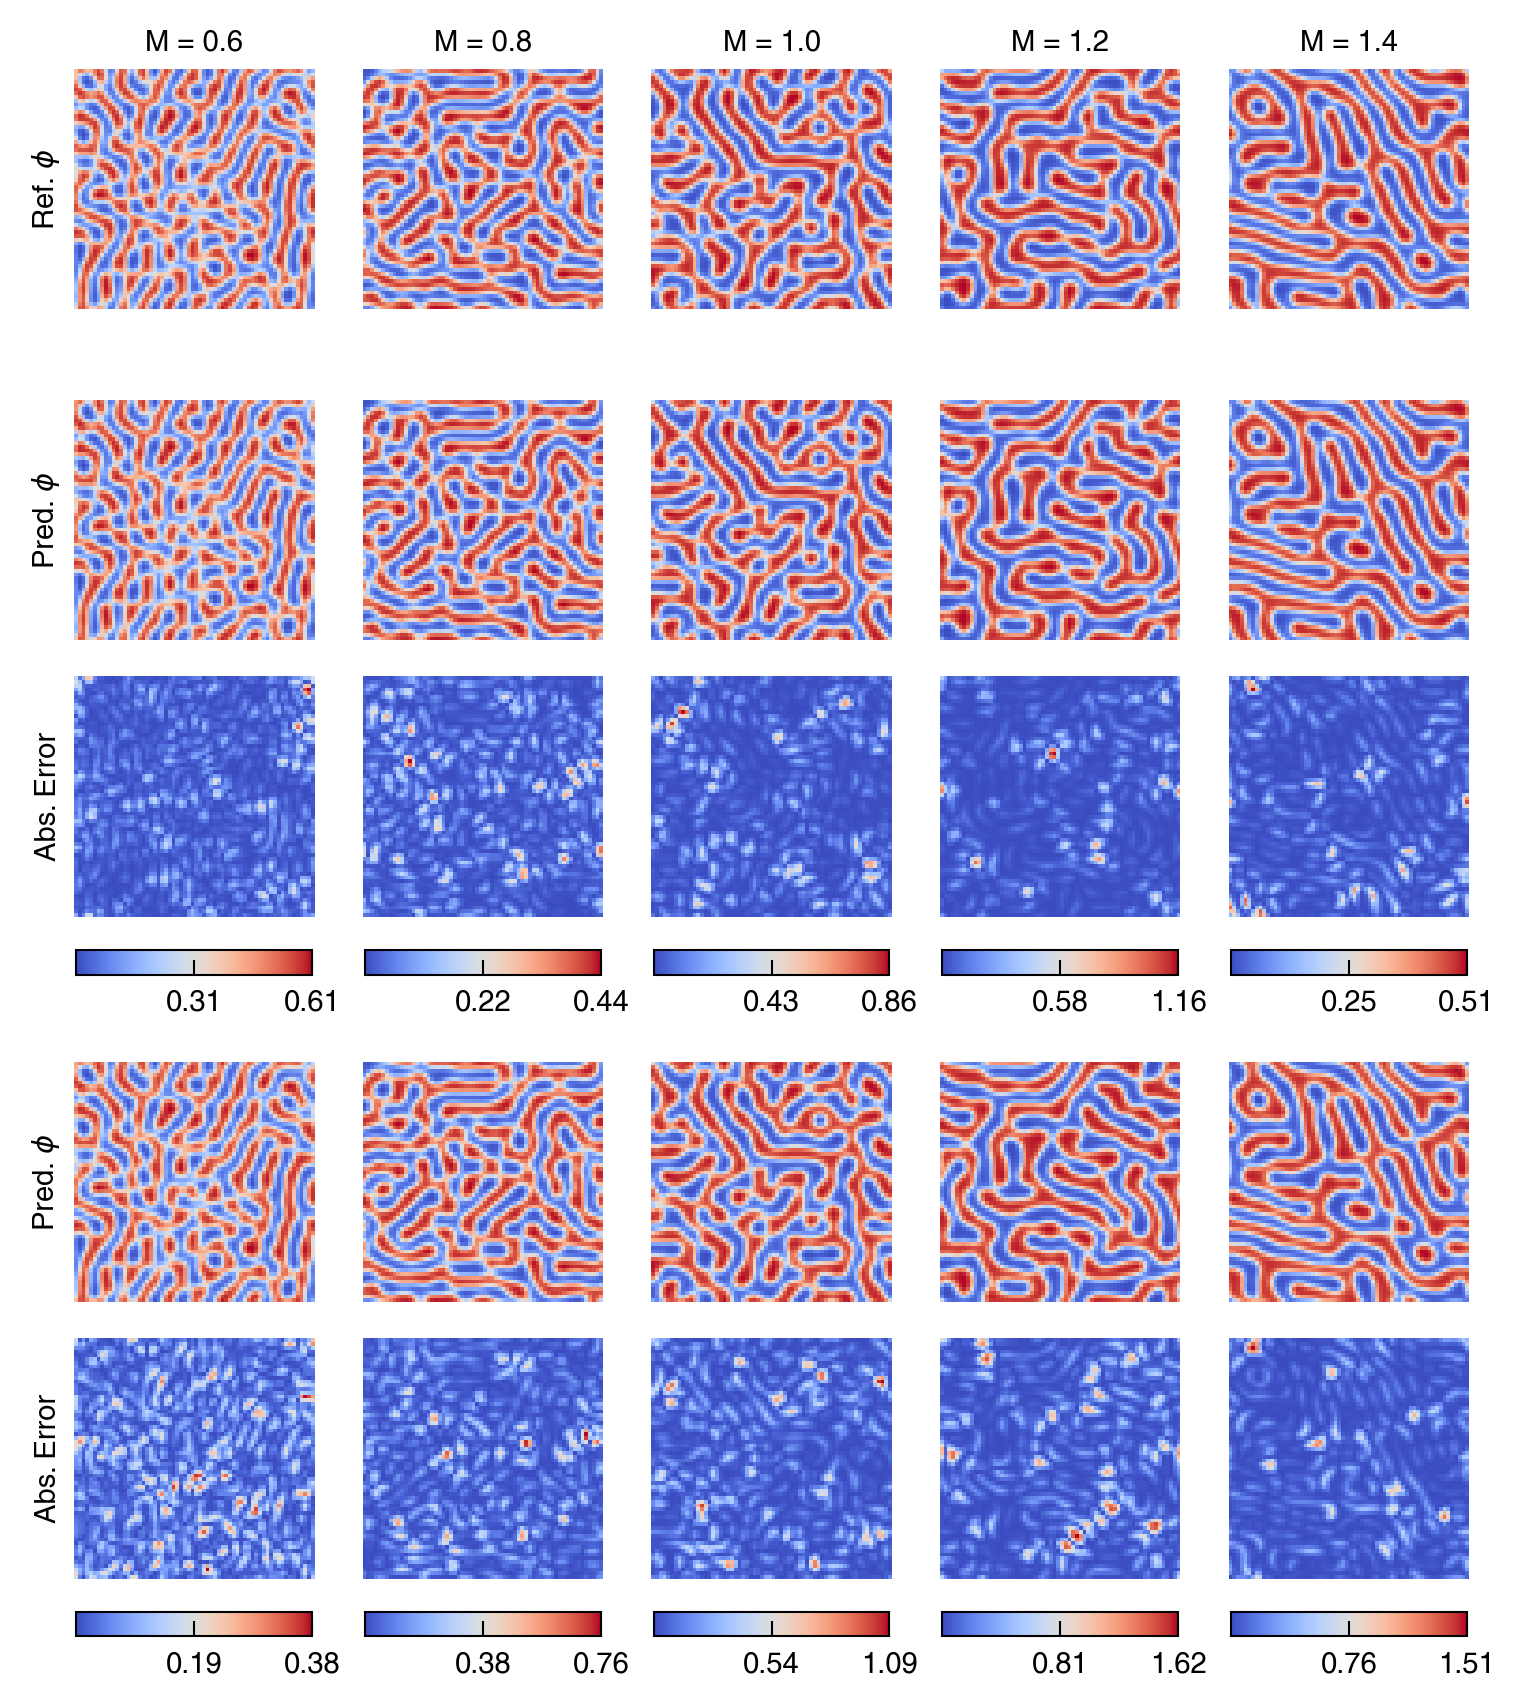

In [12]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3,4]
idx = -1
component = 0
from matplotlib import gridspec
fig = plt.figure(figsize=(1.2 * len(example_ths), 6.8))
gs = gridspec.GridSpec(9, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,0.1,1,1,0.1,0.1,1,1,0.1]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"M = {test_ms[example_th]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[2, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[4, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.01, 0.0, 0.98, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = figure.add_subplot(gs[5, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[6, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[7, i])
    diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[8, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.01, 0.0, 0.98, 1.0])
    fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3), )
    
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_test_final_shape_phi.pdf"), bbox_inches='tight', dpi=450)

In [13]:
u_preds.shape, u_preds_fno.shape, y_test.shape

((5, 100, 1, 64, 64), (5, 100, 1, 64, 64), (5, 100, 1, 64, 64))

In [14]:
dx = float(meshesx[0,1] - meshesx[0,0])
dy = float(meshesy[1,0] - meshesy[0,0])
dx,

(0.015625,)

In [24]:
import numpy as np
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import directed_hausdorff

def hausdorff_from_arrays(pred, ref, dx=1.0):
    pred_mask = pred >= 0.
    ref_mask  = ref  >= 0.

    pred_bd = find_boundaries(pred_mask, mode='inner')
    ref_bd  = find_boundaries(ref_mask,  mode='inner')

    pred_pts = np.column_stack(np.nonzero(pred_bd))
    ref_pts  = np.column_stack(np.nonzero(ref_bd))

    d1 = directed_hausdorff(pred_pts, ref_pts)[0]
    d2 = directed_hausdorff(ref_pts, pred_pts)[0]

    return max(d1, d2)

hd_distances_pino = []
hd_distances_fno = []
for example_th in range(1,y_test.shape[0]):
    y_test_final = np.array(y_test[example_th, -1, 0, :, :])
    u_preds_final = np.array(u_preds[example_th, -1, 0, :, :])
    u_preds_fno_final = np.array(u_preds_fno[example_th, -1, 0, :, :])
    hd_distance_pino = hausdorff_from_arrays(u_preds_final, y_test_final, dx=dx)
    hd_distance_fno = hausdorff_from_arrays(u_preds_fno_final, y_test_final, dx=dx)
    hd_distances_pino.append(hd_distance_pino)
    hd_distances_fno.append(hd_distance_fno)
    
# use relative hd distance, normalized by mesh size
hd_distances_pino = np.array(hd_distances_pino)
hd_distances_fno = np.array(hd_distances_fno)
print("PINO Hausdorff Distance (mean ± std): "+
      f"{hd_distances_pino.mean():.4f} ± {hd_distances_pino.std():.4f} (normalized by dx)")
print("FNO Hausdorff Distance (mean ± std): "+
      f"{hd_distances_fno.mean():.4f} ± {hd_distances_fno.std():.4f} (normalized by dx)")


PINO Hausdorff Distance (mean ± std): 1.5590 ± 0.5652 (normalized by dx)
FNO Hausdorff Distance (mean ± std): 1.9716 ± 0.3359 (normalized by dx)


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


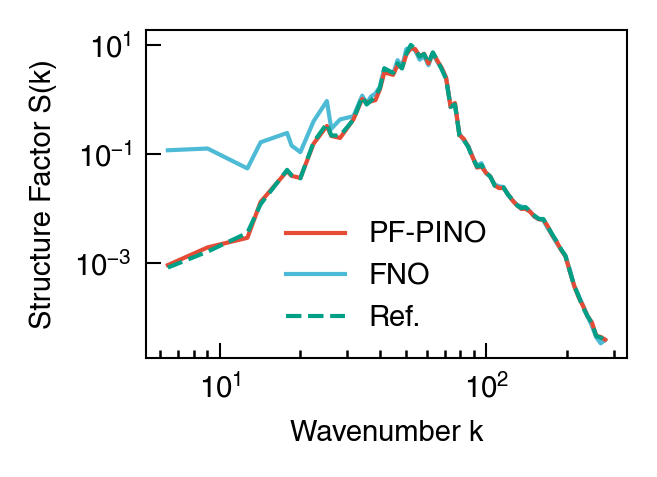

In [105]:
# 计算最终step的结构因子
def ensemble_structure_factor(fields, dx=1.0, dy=None, nbins=80):
    """计算一组场的平均结构因子

    Args:
        fields: jnp.ndarray, shape [samples, nx, ny]
        dx: float, 网格在x方向的间距
        dy: float, 网格在y方向的间距
        nbins: int, 计算径向平均时的bins数量

    Returns:
        k_centers: jnp.ndarray, shape [nbins], 波数中心值
        S_mean: jnp.ndarray, shape [nbins], 平均结构因子
    """

    def radial_average_psd(field, dx=1.0, dy=None, nbins=80):
        """计算单个场的径向平均功率谱密度

        Args:
            field: jnp.ndarray, shape [nx, ny]
            dx: float, 网格在x方向的间距
            dy: float, 网格在y方向的间距
            nbins: int, 计算径向平均时的bins数量

        Returns:
            k_centers: jnp.ndarray, shape [nbins], 波数中心值
            S_mean: jnp.ndarray, shape [nbins], 径向平均功率谱密度
        """
        nx, ny = field.shape
        fx = jnp.fft.fftfreq(nx, d=dx)
        fy = jnp.fft.fftfreq(ny, d=dy)
        kx = jnp.fft.fftshift(fx) * 2 * jnp.pi
        ky = jnp.fft.fftshift(fy) * 2 * jnp.pi
        KX, KY = jnp.meshgrid(kx, ky, indexing='ij')
        K = jnp.sqrt(KX**2 + KY**2)

        F_field = jnp.fft.fft2(field)
        F_field_shifted = jnp.fft.fftshift(F_field)
        PSD = jnp.abs(F_field_shifted)**2 / (nx * ny)

        k_flat = K.ravel()
        psd_flat = PSD.ravel()
        
        # 使用对数间距划分
        k_min = k_flat[k_flat > 0].min()
        k_max = k_flat.max()
        k_bins = jnp.logspace(jnp.log10(k_min), jnp.log10(k_max), nbins + 1)
        
        # 使用 histogram 计算每个 bin 的总能量和点数
        hist_sum, _ = jnp.histogram(k_flat, bins=k_bins, weights=psd_flat)
        hist_counts, _ = jnp.histogram(k_flat, bins=k_bins)
        
        # 计算平均值，避免除以 0
        S_mean = jnp.where(hist_counts > 0, hist_sum / hist_counts, 0.0)
        k_centers = jnp.sqrt(k_bins[:-1] * k_bins[1:]) # 对数中点
        
        # 过滤掉 S_mean 为 0 的点
        mask = S_mean > 0
        return k_centers[mask], S_mean[mask]
    
    S_ensemble = []
    for i in range(fields.shape[0]):
        _, S = radial_average_psd(fields[i], dx=dx, dy=dy, nbins=nbins)
        S_ensemble.append(S)
    S_ensemble = jnp.stack(S_ensemble, axis=0)
    S_mean = jnp.mean(S_ensemble, axis=0)
    k_centers, _ = radial_average_psd(fields[0], dx=dx, dy=dy, nbins=nbins)
    return k_centers, S_mean

k, S_gt = ensemble_structure_factor(y_test[:, -1, 0, :, :], dx=dx, dy=dy, nbins=100)
_, S_pino = ensemble_structure_factor(u_preds[:, -1, 0, :, :], dx=dx, dy=dy, nbins=100)
_, S_fno = ensemble_structure_factor(u_preds_fno[:, -1, 0, :, :], dx=dx, dy=dy, nbins=100)
fig, ax = plt.subplots(1,1, figsize=(2.2,1.6))

ax.loglog(k, S_pino, label='PF-PINO', lw=1)
ax.loglog(k, S_fno, label='FNO', lw=1, zorder=-1)
ax.loglog(k, S_gt, label='Ref.', lw=1, ls='--')
ax.legend()
ax.set_xlabel('Wavenumber k')
ax.set_ylabel("Structure Factor S(k)")
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_structure_factor_comparison.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


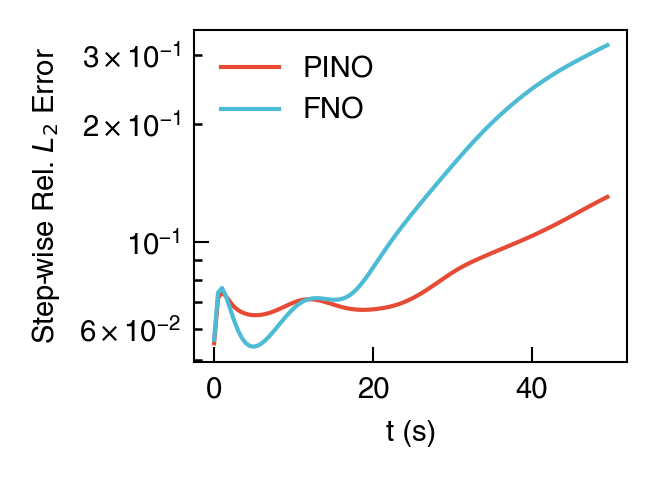

In [102]:

step_wise_l2_pino = jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
step_wise_l2_fno = jnp.linalg.norm(y_test - u_preds_fno, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
# step_wise_l2_pino = jnp.mean(step_wise_l2_pino[2:], axis=(0, 2)) # avg over samples and channels
# step_wise_l2_fno = jnp.mean(step_wise_l2_fno[2:], axis=(0, 2)) # avg over samples and channels

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
ts = jnp.arange(step_wise_l2_pino.shape[1]) * dt


ax.plot(ts, jnp.mean(step_wise_l2_pino[-2:], axis=(0, 2)), label="PINO", lw=1, color="C0")
ax.plot(ts, jnp.mean(step_wise_l2_fno[-2:], axis=(0, 2)), label="FNO", lw=1,  color="C1")
ax.set_yscale("log")
ax.set_xlabel(r"t (s)")
ax.set_ylabel("Step-wise Rel. $L_2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_stepwise_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)


In [103]:
epochs = jnp.arange(0, 5001, configs.test_every)

l2_pino_list = []
l2_fno_list = []

def compute_l2(model, x_test, y_test, test_meshes, test_ks):
    auto_reg_fn = partial(
        model.auto_reg,
        meshes=test_meshes,
        steps=100,
    )
    y_test_pred = jax.vmap(auto_reg_fn, in_axes=(0, 0))(x_test, test_ks)

    # shape [sample, T, channel, spatialx, spatialy]
    # compute l2 on T, x, y
    l2 = jnp.sqrt(jnp.sum((y_test_pred - y_test) ** 2, axis=(1,3,4)) / jnp.sum(y_test ** 2, axis=(1,3,4)))
    l2 = l2[3:]
    l2 = jnp.mean(l2)  # avg over samples and channels
    return l2
    
for epoch in epochs:
    weight_fno = os.path.join(save_dir_fno, f"epoch_{epoch}.eqx")
    model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)
    l2_fno = compute_l2(model_fno, u0, y_test, meshes, test_ms)
    l2_fno_list.append(l2_fno)


epochs = jnp.arange(0, 2500, 50)
for epoch in epochs:
    weight_pino = os.path.join(save_dir_fno, f"fine_tuned_epoch_{epoch}.eqx") # fined tuned model still saved in FNO dir
    model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
    l2_pino = compute_l2(model_pino, u0, y_test, meshes, test_ms)
    l2_pino_list.append(l2_pino)

print("Final PINO Fine-tuned L2:", l2_pino_list[-1])
print("Final FNO L2:", l2_fno_list[-1])


Final PINO Fine-tuned L2: 0.096938655
Final FNO L2: 0.32406092


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Minimum L2 errors during training:
PINO Fine-tuned: 0.09693865478038788
FNO: 0.20568111538887024


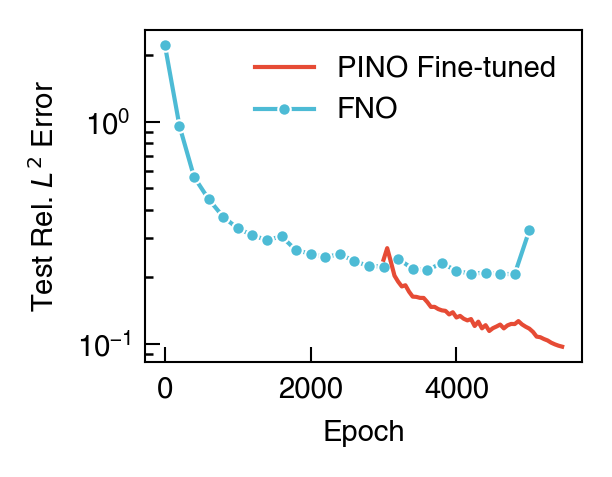

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(2.05, 1.6))
# l2_pino = jnp.array(l2_pino_list) * 0.8
# l2_pino = l2_pino.at[-4].set(l2_pino[-4] * 0.6)
ax.plot(jnp.arange(0, 2500, 50)+3000, l2_pino_list, label="PINO Fine-tuned", 
        lw=1, )
ax.plot(jnp.arange(0, 5001, configs.test_every), l2_fno_list, label="FNO", lw=1, marker='o', markersize=3,
        markeredgecolor="white", markeredgewidth=0.5, zorder=-1)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_test_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

print("Minimum L2 errors during training:")
print(f"PINO Fine-tuned: {min(l2_pino_list)}")
print(f"FNO: {min(l2_fno_list)}")

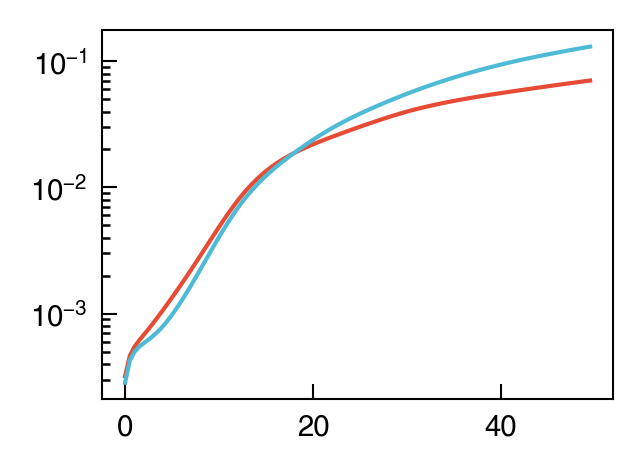

In [16]:
# mass_frac_pino = jnp.mean((u_preds[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
# mass_frac_fno = jnp.mean((u_preds_fno[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
# mass_frac_gt = jnp.mean((y_test[:, :, 0, ...] + 1) / 2, axis=(-1,-2))
mass_pino = (u_preds[:, :, 0, ...] + 1) / 2
mass_fno = (u_preds_fno[:, :, 0, ...] + 1) / 2
mass_gt = (y_test[:, :, 0, ...] + 1) / 2

mass_l2_pino = jnp.linalg.norm(mass_gt - mass_pino, axis=(-1,-2)) / jnp.linalg.norm(mass_gt, axis=(-1,-2))
mass_l2_fno = jnp.linalg.norm(mass_gt - mass_fno, axis=(-1,-2)) / jnp.linalg.norm(mass_gt, axis=(-1,-2))
mass_l2_pino = jnp.mean(mass_l2_pino, axis=0) # avg over samples
mass_l2_fno = jnp.mean(mass_l2_fno, axis=0) # avg over samples

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
ts = jnp.arange(mass_l2_pino.shape[0]) * dt
ax.plot(ts, mass_l2_pino, label="PINO", lw=1, color="C0")
ax.plot(ts, mass_l2_fno, label="FNO", lw=1,  color="C1")
ax.set_yscale("log")

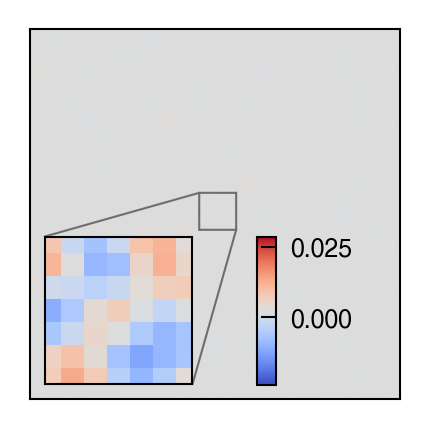

In [17]:
# plot a sample u0
u0_sample = u0[0, 0]
fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.6))
ax.pcolormesh(meshesx, meshesy, u0_sample, shading='auto', cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)

# zoom in a minimum region
# we select the region where x in [0.4, 0.6] and y in [0.4, 0.6]
# and plot that region in an inset axis
region = [0.45, 0.55, 0.45, 0.55]  # [x_min, x_max, y_min, y_max]
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="40%", height="40%", 
                   bbox_to_anchor=(0.0, 0.0, 1.0, 1.0),
                   loc="lower left",
                   bbox_transform=ax.transAxes, )

axins.pcolormesh(meshesx, meshesy, u0_sample, shading='auto', cmap='coolwarm', rasterized=True)
axins.set_xlim(region[0], region[1])
axins.set_ylim(region[2], region[3])
axins.set_xticks([])
axins.set_yticks([])

# add a colorbar right to the inset axis
ax_inset_cb = fig.add_axes([0.6,
                           0.14,
                           0.04,
                           axins.get_position().height*0.4])
cbar = fig.colorbar(axins.collections[0], cax=ax_inset_cb)
cbar.ax.tick_params(labelsize=6)


# set limits
# ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.indicate_inset_zoom(axins, edgecolor="black", lw=0.5)
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_u0.pdf"), dpi=450,  pad_inches=0.0)

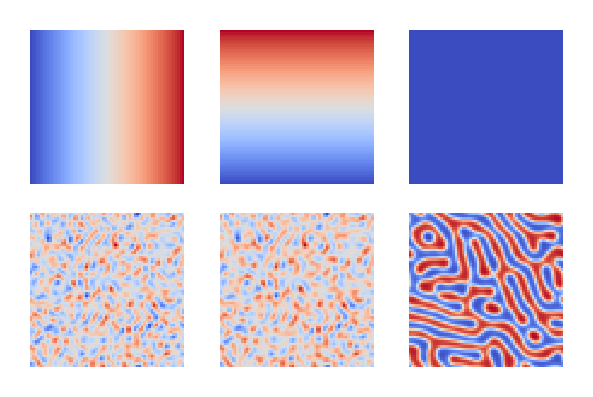

In [18]:
# show: meshesx, meshesy, M_value, u0, u1, u_last

fig, axes = plt.subplots(2, 3, figsize=(2, 4/3))
axes = axes.flatten()

# plot meshesx
ax = axes[0]
ax.pcolormesh(meshesx, meshesy, meshesx, shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

# plot meshesy
ax = axes[1]
ax.pcolormesh(meshesx, meshesy, meshesy, shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

# plot M_value as a constant field
ax = axes[2]
M_value = test_ms[0]
M_field = jnp.ones_like(meshesx) * M_value
ax.pcolormesh(meshesx, meshesy, M_field, shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

# plot u0
ax = axes[3]
ax.pcolormesh(meshesx, meshesy, u0[-1, 0], shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

# plot u1
ax = axes[4]
ax.pcolormesh(meshesx, meshesy, y_test[-1, 0, 0], shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

# plot u_last
ax = axes[5]
ax.pcolormesh(meshesx, meshesy, y_test[-1, -1, 0], shading='auto', cmap='coolwarm', rasterized=True)
ax.set_axis_off()
ax.set_aspect('equal')

fig.tight_layout()
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_display_inputoutput.pdf"), dpi=450,  pad_inches=0.0)

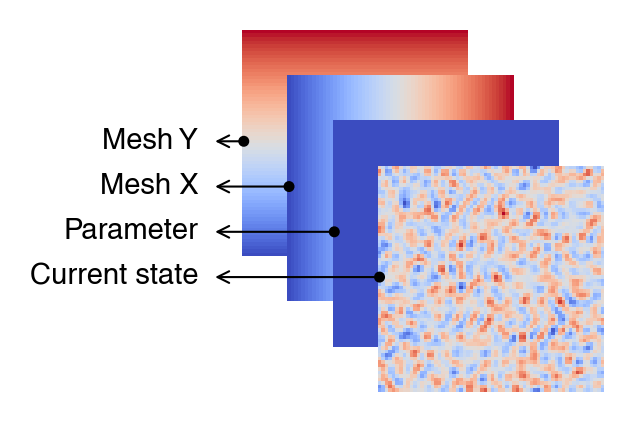

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.6))

ax.pcolormesh(meshesx, meshesy, meshesy, shading='auto', cmap='coolwarm', rasterized=True)
ax.pcolormesh(meshesx+0.2, meshesy-0.2, meshesx, shading='auto', cmap='coolwarm', rasterized=True)
ax.pcolormesh(meshesx+0.4, meshesy-0.4, M_field, shading='auto', cmap='coolwarm', rasterized=True)
ax.pcolormesh(meshesx+0.6, meshesy-0.6, u0[-1, 0], shading='auto', cmap='coolwarm', rasterized=True)

ax.annotate('Mesh Y', xy=(0.+0.05, 0.5), xytext=(-0.2, 0.5),
            arrowprops=dict(facecolor='black', arrowstyle='<-', lw=0.5),
            color='black', ha='right', va='center')

ax.annotate('Mesh X', xy=(0.2+0.05, 0.3), xytext=(-0.2, 0.3),
            arrowprops=dict(facecolor='black', arrowstyle='<-', lw=0.5),
            color='black', ha='right', va='center')

ax.annotate("Parameter", xy=(0.4+0.05, 0.1), xytext=(-0.2, 0.1),
            arrowprops=dict(facecolor='black', arrowstyle='<-', lw=0.5),
            color='black', ha='right', va='center')

ax.annotate("Current state", xy=(0.6+0.05, -0.1), xytext=(-0.2, -0.1),
            arrowprops=dict(facecolor='black', arrowstyle='<-', lw=0.5),
            color='black', ha='right', va='center')

# plot little circles to indicate the four inputs
from matplotlib.patches import Circle
circle1 = Circle((0., 0.5), 0.015, color='black', fill=True)
circle2 = Circle((0.2, 0.3), 0.015, color='black', fill=True)
circle3 = Circle((0.4, 0.1), 0.015, color='black', fill=True)
circle4 = Circle((0.6, -0.1), 0.015, color='black', fill=True)
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(circle4)


ax.set_aspect('equal')
ax.set_axis_off()

fig.tight_layout()
# fig.savefig(os.path.join(save_fig_dir, "spinodal_decomposition_input_illustration.pdf"), dpi=450,  pad_inches=0.0)

array([[0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       ...,
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375]],
      shape=(64, 64))